# Name-free labels for free-vocabulary NL→FOL translations: dataset builder demo

This notebook is a runnable walk-through of **`data.py`**, the script that packages the **T7b name-free label dataset** (`full_data_out.json`, `exp_sel_data_out` format). The dataset supports gold-free faithfulness metrics for natural-language → first-order-logic (NL→FOL) translation.

**Where the labels come from.** Ten LLM slots from 9 model families translated 221 templated rule sentences into FOL. Each model could name its predicates freely (FREE condition). The model's predicate names never match the template's reference vocabulary, so ordinary "equivalent to the gold formula" labelling does not apply. Each candidate was therefore labelled by an **exhaustive, certificate-backed, name-free map search** (`src/freelab.py`):
- the search enumerates every injective map from candidate symbols to template atoms, including reification (B1/B2), merge (B3), split (B4) and lexical-negation (B5) bridges;
- sound z3 relevance/polarity checks and 128-model finite countermodel fingerprints prune the search;
- z3 then checks equivalence for every surviving map.

A candidate with **no** equivalent map is `ERROR_CERT` (a certified error, relative to the map family). A candidate with at least one z3-equivalent map is `UNRESOLVED_GLOSS_NOT_RUN`: it still needs an LLM *gloss check* (does each mapped symbol actually mean the template atom?). That check could not run because the run's API budget was exhausted (deviation **D9**).

`data.py` assembles three groups:

| group | rows (full) | what it is |
|---|---|---|
| `rcomp_free_labels` | 2,652 | one row per FREE generation: (text, candidate FOL) → name-free label + map certificate + strata |
| `gloss_gate_items` | 840 | known-answer (symbol use, meaning) items, 7 classes × 120, halves A/B, for validating the gloss checker |
| `sig_soundness_replay` | 4,280 | 2,140 fixed-vocabulary (SIG) rows renamed with nonce/synonym names, with known pure-z3 labels, for testing the soundness of the name-free search |

The notebook runs the **original assembly code** from `data.py` and `src/build_output.py` with minimal changes. It reads a curated subset of the raw inputs from `mini_demo_data.json` (60 FREE rows, 20 gate items and 20 SIG rows, stratified), not from `results/*.jsonl`. The seal and testability summary come from the full dataset.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (data.py's only dependency)
_pip('loguru==0.7.3')

# pandas, matplotlib — pre-installed on Colab, install locally only (used for the results/visualization cells)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports and logging setup

This is the import and logger block from `data.py`, unchanged except that `ROOT` is the notebook's working directory (a notebook has no `__file__`). The `sys.path` inserts for `src/` and `vendor/` are dropped because the functions they provided are copied into cells below. `json` and `Path` stand in for the imports of `src/common.py`. `pandas` and `matplotlib` are added for the results cells.

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

ROOT = Path.cwd()  # original: Path(__file__).resolve().parent

from loguru import logger  # noqa: E402

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

# extra imports for the notebook's summary/visualization cells
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

## Load the demo data

The curated inputs are fetched from GitHub. If that fails (for example before the repository is published), the notebook falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-4/dataset-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: len(v) for k, v in data.items() if isinstance(v, (list, dict)) and k != "description"})

Curated demo subset of the raw inputs read by data.py/src/build_output.py (art_Ia_FT284H33j): 60 FREE label rows (stratified over label x model family), 20 gloss-gate items (class x half), 20 SIG replay rows (rename x label x search status) + the sentences they need, the label seal and testability summary of the FULL dataset.
{'free_labels_v2': 60, 'gate_items': 20, 'sig_replay_rows': 20, 'sentences': 18, 'seal': 1, 'testability_FREE_v2': 3}


## Configuration

`data.py` has only one fixed setting: `SELECTED`, the groups written to the output. The row limits below are notebook additions. They cap how many rows of each raw input are packaged. The originals had no cap: 2,652 FREE rows, 840 gate items and 4,280 SIG replay rows from `results/`. The demo file holds 60 / 20 / 20. `None` means "use every row in the loaded demo data".

In [5]:
SELECTED = ["rcomp_free_labels", "gloss_gate_items", "sig_soundness_replay"]

# rows taken from each raw input (original: all rows of results/free_labels_v2.jsonl (2,652),
# results/gate_items.json (840), results/sig_replay_rows.jsonl (4,280)); None = all rows in mini_demo_data.json
N_FREE = None
N_GATE = None
N_SIG = None

## Group 1: `rcomp_free_labels`, one row per FREE generation

This is `free_group()` from `src/build_output.py`. Each example's `input` is a JSON string holding the sentence, the candidate FOL and the generating system, family, slot and prompt variant. Its `output` is the name-free label:

- `ERROR_CERT`: no map in the declared family makes the candidate z3-equivalent to any template reading. The label is final, with certificate counts such as `count_prune_subtree` (subtrees pruned by a certified finite countermodel) and `no_polarity_compatible_target`.
- `UNRESOLVED_GLOSS_NOT_RUN`: at least one z3-equivalent map exists (`map_certificate` lists it). The gloss check that decides CORRECT vs ERROR is pending.
- `UNPARSEABLE` / `NO_OUTPUT`: coverage failures. They are kept as rows, not dropped.

`label_binary_search_provisional` collapses these to ERROR / MAPPED / EXCLUDED. The only change from the original is the input source: rows come from `data["free_labels_v2"]` instead of `load_jsonl(RES / "free_labels_v2.jsonl")`.

In [6]:
def md(d: dict) -> dict:
    return {f"metadata_{k}": v for k, v in d.items()}


def free_group() -> dict:
    rows = data["free_labels_v2"][:N_FREE]  # original: load_jsonl(RES / "free_labels_v2.jsonl")
    ex = []
    for r in rows:
        inp = {"text": r["text"], "candidate_fol": r["candidate_fol"], "system": r["system"], "family": r["family"],
               "slot": r["slot"], "prompt_variant": r["prompt_variant"], "condition": "FREE", "template_id": r["template_id"]}
        search_bin = {"ERROR_CERT": "ERROR", "UNRESOLVED_GLOSS_NOT_RUN": "MAPPED"}.get(r["label"], "EXCLUDED")
        meta = {
            "row_key": r["row_key"], "item_id": r["item_id"], "sentence_id": r["sentence_id"], "template_id": r["template_id"],
            "clause_type": r["clause_type"], "words": r["words"], "word_tercile": r["word_tercile"],
            "nconds_weak": r["nconds_weak"], "negated_condition": r["negated_condition"], "nested": r["nested"],
            "label_binary": r["label_binary"], "label_binary_search_provisional": search_bin,
            "label_source": r["label_source"], "search_status": r.get("search_status"),
            "matched_reading": r.get("matched_reading") or r.get("matched_reading_search"),
            "map_certificate": r.get("map_certificate"),
            "n_maps_enumerated": r.get("n_maps_enumerated"), "n_maps_fingerprint_pass": r.get("n_maps_fingerprint_pass"),
            "n_equiv_maps": r.get("n_equiv_maps"), "n_equiv_map_orbits": r.get("n_equiv_map_orbits"),
            "nonequiv_certificate_type_counts": r.get("nonequiv_certificate_type_counts"),
            "gloss_pairs": r.get("gloss_pairs"), "gloss_decision": r.get("gloss_decision"),
            "unresolved_reason": r.get("unresolved_reason"), "irrelevant_symbols": r.get("irrelevant_symbols"),
            "search_secs": r.get("search_secs"), "seen_iter3": r.get("seen_iter3"),
            "old_label_iter3": r.get("old_label_iter3"), "fold": "RCOMP_FREE"}
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": r["label"], **md(meta)})
    return {"dataset": "rcomp_free_labels", "examples": ex}

## Group 2: `gloss_gate_items`, known-answer items for the gloss checker

This is `gate_group()`. Each item asks: "in this sentence, does candidate atom `A` mean `proposed_meaning`?" The gold answer is YES or NO. There are 7 classes:
- YES classes: identical wording (`YES_IDENT`), synonym (`YES_SYN`), different surface form (`YES_FORM`);
- NO classes: nonce name (`NO_NONCE`), meaning taken from another atom (`NO_DONOR`), swapped role (`NO_ROLE`), two atoms merged (`NO_MERGE`).

A gloss checker must pass these items before its verdicts can turn MAPPED rows into CORRECT or ERROR. The Haiku and Qwen verdicts are still `null` because of deviation D9. Only the input source changed.

In [7]:
def gate_group() -> dict:
    items = data["gate_items"][:N_GATE]  # original: json.loads((RES / "gate_items.json").read_text())
    ex = []
    for i in items:
        inp = {"sentence": i["sentence"], "candidate_atom": i["candidate_atom"], "proposed_meaning": i["proposed_meaning"]}
        meta = {"item_id": i["item_id"], "class": i["class"], "half": i["half"], "sentence_id": i["sentence_id"],
                "template_id": i["template_id"], "note": i["note"], "prompt_version": "gloss_v1",
                "haiku_verdict": i.get("haiku_gloss_v1"), "qwen_verdict": i.get("qwen_gloss_v1"), "fold": "GLOSS_GATE"}
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": i["gold"], **md(meta)})
    return {"dataset": "gloss_gate_items", "examples": ex}

## Group 3: `sig_soundness_replay`, renamed SIG rows with known labels

This is `sig_group()`. The SIG condition used the template's own vocabulary, so its labels are pure z3 (equivalent to a template reading or not). Each SIG candidate is renamed twice, with **nonce** names (`Buzil`, `Getoz`, …) and with **synonyms**, and the name-free search is re-run on it. The known labels expose:
- *false ERROR_CERT*: the search certifies an error on a row known to be CORRECT (0/1,595 in the full data);
- *identity-map recovery*: the search finds the true renaming back to the template vocabulary (100%);
- *rescue*: known errors that some non-identity map makes equivalent (9–10%). The gloss check has to catch these.

`sentences` supplies the text for each `sentence_id`. Only the two input sources changed.

In [8]:
def sig_group() -> dict:
    sents = data["sentences"]  # original: json.loads((WORK / "sentences.json").read_text())
    rows = data["sig_replay_rows"][:N_SIG]  # original: load_jsonl(RES / "sig_replay_rows.jsonl")
    ex = []
    for r in rows:
        inp = {"text": sents[r["sentence_id"]]["text"], "candidate_fol": r["renamed_fol"], "rename": r["rename"],
               "template_id": r["template_id"]}
        meta = {k: r[k] for k in ("row_key", "sentence_id", "slot", "template_id", "sig_matched_reading", "canon_fol",
                                  "search_status", "identity_map_found", "non_identity_map_found", "n_equiv_maps",
                                  "n_equiv_map_orbits", "n_maps_enumerated", "nonequiv_certificate_type_counts",
                                  "oracle_end_to_end_label", "in_e2e_gloss_subsample_300", "e2e_gloss_label")}
        meta["map_equiv_found"] = r["search_status"] in ("MAPPED", "READING_CHOICE")
        meta["fold"] = f"SIG_REPLAY_{r['rename'].upper()}"
        ex.append({"input": json.dumps(inp, ensure_ascii=False), "output": r["sig_label"], **md(meta)})
    return {"dataset": "sig_soundness_replay", "examples": ex}

## Assemble `full_data_out.json`, as in `data.py`'s `main()`

This cell builds the three groups and runs the original schema assertions: string `input`/`output`, and no reserved `split`/`dataset`/`context` keys. It then attaches the label **seal** (a sha256 of the full label vector, recorded under a hashed pre-registration) and the testability summary, and writes the JSON. The only change from the original is the source of `seal` and `t` (the loaded data instead of `results/*.json`). The seal and testability numbers describe the **full** 2,652-row dataset. The examples are the demo subset.

In [9]:
@logger.catch(reraise=True)
def main() -> None:
    groups = [free_group(), gate_group(), sig_group()]
    for g in groups:
        assert g["examples"], g["dataset"]
        for e in g["examples"]:
            assert isinstance(e["input"], str) and isinstance(e["output"], str), g["dataset"]
            assert not ({"split", "dataset", "context"} & set(e)), g["dataset"]
    seal = data["seal"]["seals"][-1]  # original: json.loads((ROOT / "results" / "seal.json").read_text())["seals"][-1]
    t = data["testability_FREE_v2"]  # original: json.loads((ROOT / "results" / "testability_FREE_v2.json").read_text())
    out = {"metadata": {
        "artifact": "T7b name-free labels for free-vocabulary rule translations (run_u75jRHUss0zo, iter 4, gen_art_dataset_5)",
        "workspace": str(ROOT),
        "selection": ("the three plan groups (chosen as best 3 of 6 standardised candidates; folio / malls_test / "
                      "logicnli_test were context only: no multi-system candidates, ~36-39% wrong gold, or no FOL; their "
                      "standardised record is temp/candidates_data_out.json)"),
        "label_mode": seal["mode"],
        "status_note": ("SEARCH-ONLY labels: the paid gloss step could not run (deviation D9: run OpenRouter budget "
                        "exhausted before this artifact's first call; re-probed at packaging, still HTTP 403). ERROR_CERT is "
                        "final and certificate-backed; MAPPED rows are UNRESOLVED_GLOSS_NOT_RUN until src/resume_gloss.py "
                        "runs. metadata_label_binary_search_provisional (ERROR vs MAPPED) is a provisional view with audited "
                        "contamination (results/soundness_audit.json)."),
        "seal_all_rows_sha256": seal["label_vector_sha256_all_rows"],
        "seal_untouched_sha256": seal.get("label_vector_sha256_untouched"),
        "prereg_sha256": seal["prereg_sha256"],
        "testability_all_rows": {k: t["all_rows"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "testability_untouched": {k: t["untouched_subset"][k] for k in ("n_ERROR", "n_CORRECT", "TESTABLE", "label_counts")},
        "provisional_view_testable": {k: t["search_provisional_view"][k]["TESTABLE"] for k in ("all_rows", "untouched_subset")},
    }, "datasets": [g for g in groups if g["dataset"] in SELECTED]}
    (ROOT / "full_data_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"full_data_out.json: {[(g['dataset'], len(g['examples'])) for g in out['datasets']]}")


main()

13:16:05|INFO   |full_data_out.json: [('rcomp_free_labels', 60), ('gloss_gate_items', 20), ('sig_soundness_replay', 20)]


## Results

The output file is read back and summarised:
1. dataset-level metadata: seal, testability, and why AUROC is not yet testable;
2. one worked example of each FREE label kind, including the z3-equivalent map certificate of a MAPPED row;
3. label distributions: demo subset vs full dataset, labels per model family, gate classes, and SIG-replay soundness.

In [10]:
out = json.loads((ROOT / "full_data_out.json").read_text())
M = out["metadata"]
print("label_mode:", M["label_mode"], "| seal (all rows):", M["seal_all_rows_sha256"][:16], "...",
      "| seal (untouched):", str(M["seal_untouched_sha256"])[:16], "...")
print("full-data testability (ERROR vs CORRECT):", M["testability_all_rows"]["TESTABLE"],
      f"(n_ERROR={M['testability_all_rows']['n_ERROR']}, n_CORRECT={M['testability_all_rows']['n_CORRECT']})")
print("provisional ERROR-vs-MAPPED view testable:", M["provisional_view_testable"])
print()

G = {g["dataset"]: g["examples"] for g in out["datasets"]}
free = G["rcomp_free_labels"]
for lab in ["ERROR_CERT", "UNRESOLVED_GLOSS_NOT_RUN", "UNPARSEABLE", "NO_OUTPUT"]:
    e = next((x for x in free if x["output"] == lab), None)
    if e is None:
        continue
    inp = json.loads(e["input"])
    print(f"=== {lab}  [{inp['system']}, template {inp['template_id']}, {e['metadata_words']} words]")
    print("TEXT :", inp["text"])
    print("FOL  :", inp["candidate_fol"] or "<none>")
    if e["metadata_map_certificate"]:
        c = e["metadata_map_certificate"]
        print(f"CERT : {c['status']} (reading={c['reading']}, bridges={c['bridges']})")
        for m in c["map"]:
            print("       ", m)
    if e["metadata_nonequiv_certificate_type_counts"]:
        print("non-equivalence certificates:", e["metadata_nonequiv_certificate_type_counts"])
    print()

label_mode: search_only | seal (all rows): 9609ebbb725832c4 ... | seal (untouched): b364a49a8e21835d ...
full-data testability (ERROR vs CORRECT): False (n_ERROR=759, n_CORRECT=0)
provisional ERROR-vs-MAPPED view testable: {'all_rows': True, 'untouched_subset': True}

=== ERROR_CERT  [G9:cohere/command-r7b-12-2024, template T8, 29 words]
TEXT : If a vaccine receives voice and data, is used for drinking, and emits light, then the vaccine is designed for high-performance calculations, but only if the vaccine preserves food.
FOL  : (∀x (Receive(x, voice, data) ∧ Use(x, drinking) ∧ Emit(x, light) → Design(x, highPerformanceCalculations))) ↔ (∀x (Preserve(x, food) → Design(x, highPerformanceCalculations)))
non-equivalence certificates: {'no_polarity_compatible_target': 6}

=== UNRESOLVED_GLOSS_NOT_RUN  [G9:cohere/command-r7b-12-2024, template T5, 31 words]
TEXT : Each adult who is in our family and who attends yoga classes regularly spends money, provided that the adult has ample space, exc

In [11]:
full_counts = M["testability_all_rows"]["label_counts"]
demo_counts = Counter(x["output"] for x in free)
labs = list(full_counts)
tbl = pd.DataFrame({"full (n=%d)" % sum(full_counts.values()): [full_counts[l] for l in labs],
                    "demo (n=%d)" % len(free): [demo_counts.get(l, 0) for l in labs]}, index=labs)
print("FREE label counts\n", tbl.to_string(), "\n")

fam = pd.crosstab([json.loads(x["input"])["family"] for x in free], [x["output"] for x in free], rownames=["family"], colnames=["label"])
print("FREE labels per model family (demo)\n", fam.to_string(), "\n")

gate = G["gloss_gate_items"]
print("Gloss-gate items (demo)\n", pd.crosstab([x["metadata_class"] for x in gate], [x["output"] for x in gate], rownames=["class"], colnames=["gold"]).to_string(), "\n")

sig = G["sig_soundness_replay"]
sig_df = pd.DataFrame({"rename": [json.loads(x["input"])["rename"] for x in sig],
                       "known_label": [x["output"] for x in sig],
                       "search_status": [x["metadata_search_status"] for x in sig],
                       "identity_map_found": [any(x["metadata_identity_map_found"].values()) for x in sig]})
print("SIG replay: known pure-z3 label vs name-free search outcome (demo)\n",
      pd.crosstab([sig_df["rename"], sig_df.known_label], sig_df.search_status).to_string())
n_corr = (sig_df.known_label == "CORRECT").sum()
false_err = ((sig_df.known_label == "CORRECT") & (sig_df.search_status == "ERROR_CERT")).sum()
print(f"\nfalse ERROR_CERT on known-CORRECT rows: {false_err}/{n_corr}; "
      f"identity map recovered on known-CORRECT rows: {sig_df[sig_df.known_label=='CORRECT'].identity_map_found.sum()}/{n_corr}")

FREE label counts
                           full (n=2652)  demo (n=60)
ERROR_CERT                          759           20
UNRESOLVED_GLOSS_NOT_RUN           1506           18
UNPARSEABLE                         188           18
NO_OUTPUT                           199            4 

FREE labels per model family (demo)
 label          ERROR_CERT  NO_OUTPUT  UNPARSEABLE  UNRESOLVED_GLOSS_NOT_RUN
family                                                                     
cohere                  3          0            2                         2
deepseek                3          0            2                         2
google-gemini           2          0            2                         2
google-gemma            2          0            2                         2
meta                    2          2            2                         2
microsoft               2          0            2                         2
mistral                 2          0            2                    

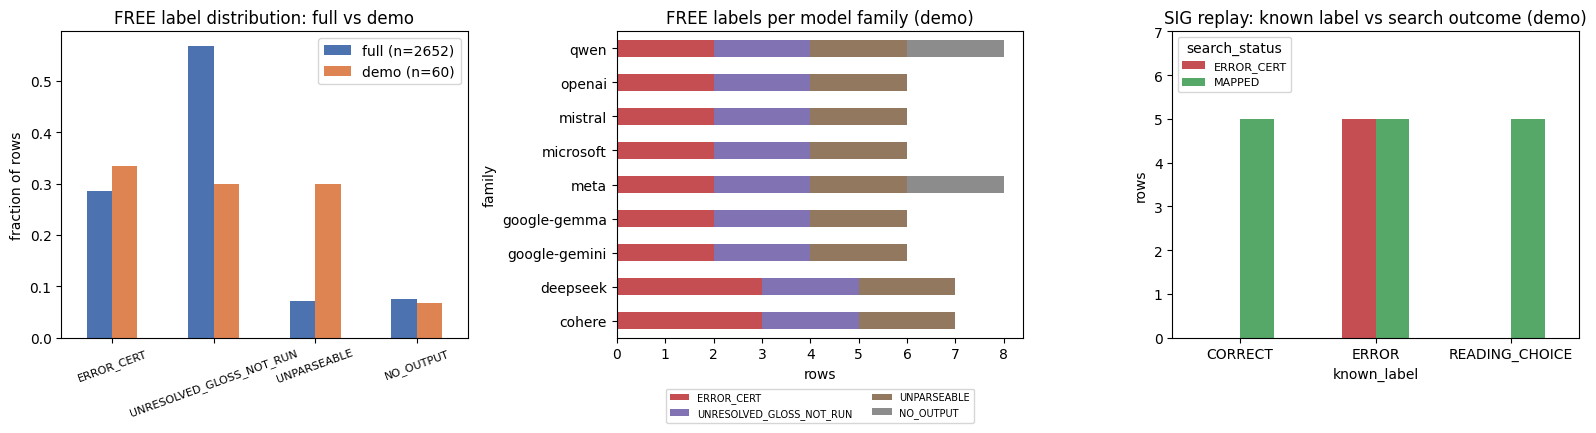

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

frac = tbl / tbl.sum()
frac.plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"], rot=20)
axes[0].set_title("FREE label distribution: full vs demo")
axes[0].set_ylabel("fraction of rows")
axes[0].tick_params(axis="x", labelsize=8)

fam.reindex(columns=labs, fill_value=0).plot.barh(stacked=True, ax=axes[1],
    color=["#C44E52", "#8172B3", "#937860", "#8C8C8C"])
axes[1].set_title("FREE labels per model family (demo)")
axes[1].set_xlabel("rows")
axes[1].legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

ct = pd.crosstab(sig_df.known_label, sig_df.search_status)
ct.plot.bar(ax=axes[2], rot=0, color=["#C44E52", "#55A868"][:ct.shape[1]])
axes[2].set_title("SIG replay: known label vs search outcome (demo)")
axes[2].set_ylabel("rows")
axes[2].legend(title="search_status", loc="upper left", fontsize=8)
axes[2].set_ylim(0, ct.values.max() + 2)

plt.tight_layout()
plt.show()

**How to read this.** `ERROR_CERT` rows are final errors relative to the declared map family. They are the only label class that exists until the gloss check runs, so an ERROR-vs-CORRECT AUROC is **NOT_TESTABLE** for now. The provisional ERROR-vs-MAPPED split is testable, but an executor audit put about 13% contamination on each side.

In the SIG replay, the search should never certify an error on a known-CORRECT row. Known-ERROR rows that land in `MAPPED` are "rescues" by non-identity maps, which the pending gloss check has to reject.

The MAPPED worked example above shows why a z3-equivalent map alone is not enough. Its certificate sends `AmpleSpace(x)` to *attends yoga regularly* and `In(x, ourFamily)` to *has ample space*. The formula is logically equivalent under this map, but the map is lexically wrong, and the gloss check exists to reject it.

To rebuild the real dataset, run `uv run data.py` inside the artifact workspace. It reads all 2,652 / 840 / 4,280 rows from `results/`. Once API budget is available, `src/resume_gloss.py` turns the MAPPED rows into final CORRECT/ERROR labels.